## Three-electrode Setup
Here we modify the code from the chain-example to include a third electrode (it can do as many as TBtrans). The purpose is to demonstrate we are not limited to the two-electrode setups we have seen before. We will again model the simple one-site chain, but now with the third electrode attatched in the middle and extending in the $y$-direction and then see how we can pump current into the third lead by changing the way the bias on each contact is phased. 

The codeblock below makes the device and contact Hamiltonians:

 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!

 set struct
done
No atoms overlapping within 0.3 Å!
self.pos is reduced coordinates, self.pos_real_space is actual coordinates!



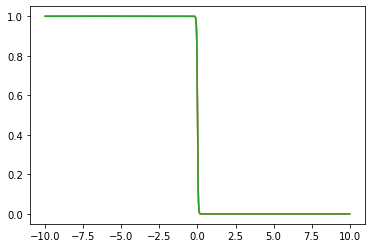

Normal plot
Running TB-Trans in Directory: Device!


 Building ES - H - Self Energies 


 Overlap Included!



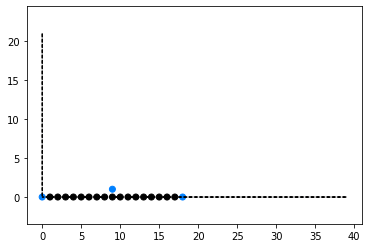

In [1]:
import numpy as np
import sisl
import matplotlib.pyplot as plt
from TimedependentTransport.TimedependentTransport import TD_Transport as TDT
from TimedependentTransport.TimedependentTransport import AdaptiveRK4  as RK4

tx = 17
t_dev =  1
t_elec = 1

lat_const = 1.0
line = np.linspace(-3 , 3, 101)  + 1j*1e-1
line = np.vstack((line,line,line))

### Geometries ###
geom_dev   = sisl.geom.sc(lat_const, sisl.Atom(1, R= 3.0)).tile(tx+2, 0).add_vacuum(10,0).add_vacuum(10,1).add_vacuum(10,2)
geom_ep    = sisl.geom.sc(lat_const, 'H').tile(1, 0).move(np.array([lat_const * (tx+1), 0, 0]))
geom_em    = sisl.geom.sc(lat_const, 'H').tile(1, 0)
geom_up    = sisl.geom.sc(lat_const, 'H').move([tx//2,0,0])

geom_dev   = geom_dev.add_vacuum(10,1).add_vacuum(10,2).add_vacuum(10,0)
geom_em    = geom_em. add_vacuum(10,1).add_vacuum(10,2)
geom_ep    = geom_ep. add_vacuum(10,1).add_vacuum(10,2)
geom_up    = geom_ep. add_vacuum(10,0).add_vacuum(10,2).move([-tx//2,1,0])
geom_dev   = geom_dev.add(geom_up)

### Our Main calculator object ###
C = TDT([geom_em,geom_ep, geom_up], geom_dev, 
         mu_i = [0.0,   0.0,   0.0  ], 
         kT_i = [0.025, 0.025, 0.025])

C.Make_Contour(line, 20 ,pole_mode = 'JieHu2011')

C.Electrodes  (semi_infs = ['-a1', '+a1', '+a2'], names = ['EM', 'EP', 'EU'],
               kp        = [[50,1,1],[50,1,1], [1,50,1]])

C.make_device(elec_inds  = [[0],  [tx+1], [tx+2]] )

elec = sisl.Hamiltonian(sisl.geom.sc(lat_const, sisl.Atom(1, R= 3.0)).add_vacuum(10,1).add_vacuum(10,2))
elec.construct([[0.1, lat_const * 1.1], 
                [0  , t_elec             ]])

elec_up = sisl.Hamiltonian(sisl.geom.sc(lat_const, sisl.Atom(1, R= 3.0)).add_vacuum(10,0).add_vacuum(10,2))
elec_up.construct([[0.1, lat_const * 1.1], 
                   [0  , t_elec/3             ]])

dev_H = sisl.Hamiltonian(geom_dev)
dev_H.construct([[0.1, lat_const * 1.1], 
                [0,    t_dev             ]])
plt.show()
C.Device.Visualise()
C.run_electrodes(fois_gras_H = [elec, elec, elec_up])
C.run_device(fois_gras_H = dev_H)
C.read_data()


Because the code is lacking plotting for more that two electrodes right now, we just load in the transmission functions manually. 

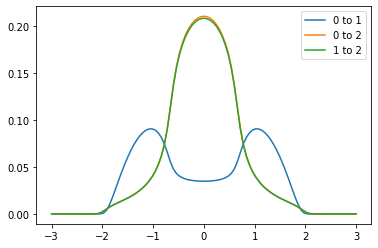

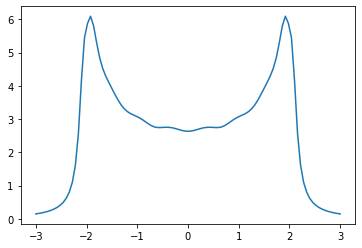

In [2]:
t = sisl.get_sile('Device/siesta.TBT.nc')
plt.plot(t.E[C.sampling_idx[0]], t.transmission(0,1)[C.sampling_idx[0]]*1.00, label = '0 to 1')
plt.plot(t.E[C.sampling_idx[0]], t.transmission(0,2)[C.sampling_idx[0]]*1.00, label = '0 to 2')
plt.plot(t.E[C.sampling_idx[0]], t.transmission(1,2)[C.sampling_idx[0]]*0.99, label = '1 to 2')
plt.legend()
plt.show()
plt.plot(t.E[C.sampling_idx[0]], t.DOS()[C.sampling_idx[0]]*0.99, label = 'Density of states')



### Fitting
We proceed to fit our self-energies. we'll however be a bit more manual at the inspection of the fits and resulting transmissions. You'll Notice when we call our fitted transmissions, the 0->1 transmission function will always be plotted. We'll just have to remember for the moment that it is the plot just above of here we have to reproduce.

In [3]:

#C.reset_all_fits() # Comment in to reset fits!
def run_mini(its):
    C.Fit(fact = 1.0,  NumL = 12,
              min_method='SLSQP',
              ebounds = (-3, 3), 
              wbounds = (0.01, 10.0), 
              gbounds = (None, None),
              tol = -1, 
              options = {'disp':True,
                         'maxiter':its, 
                         'gtol':1e-10, 
                         #'ftol':1e-10, 
                         #'iprint':1
                         },
              fit_real_part = False,
              specific_bounds = None, 
              alpha_PO = 0.01,
              cons = '')

In [4]:
run_mini(500)

Finding Lambda matrices:


/home/aleksander/Desktop/Input_hpc_master/PythonModules/Block_matrices/Block_matrices/Croy.py:319: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (array(complex128, 2d, F), array(complex128, 1d, A))
  res[ik, :, i, j] = Lorentzian_basis(M[ik, :, i, j], zi, ei[ik], gamma[ik])



--------------------
Optimizing Lorentzian Expansion
--------------------

Fitting mode for self energy!


/home/aleksander/Desktop/Input_hpc_master/PythonModules/Block_matrices/Block_matrices/Block_matrices.py:1828: OptimizeWarning: Unknown solver options: gtol
  sol = minimize(f, x0, jac = jac, method = min_method,


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.16855362433552434
            Iterations: 39
            Function evaluations: 44
            Gradient evaluations: 39
Finding Lambda matrices:

--------------------
Optimizing Lorentzian Expansion
--------------------

Fitting mode for self energy!
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.16855362433552434
            Iterations: 39
            Function evaluations: 44
            Gradient evaluations: 39
Finding Lambda matrices:


/home/aleksander/Desktop/Input_hpc_master/PythonModules/Block_matrices/Block_matrices/Block_matrices.py:1828: OptimizeWarning: Unknown solver options: gtol
  sol = minimize(f, x0, jac = jac, method = min_method,



--------------------
Optimizing Lorentzian Expansion
--------------------

Fitting mode for self energy!
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.29591502308743856
            Iterations: 34
            Function evaluations: 42
            Gradient evaluations: 34


/home/aleksander/.local/lib/python3.9/site-packages/scipy/optimize/optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


Calculating matrix elements of inverse



/home/aleksander/.local/lib/python3.9/site-packages/numpy/core/_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


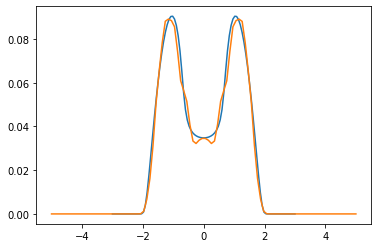

Calculating matrix elements of inverse



/home/aleksander/.local/lib/python3.9/site-packages/numpy/core/_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


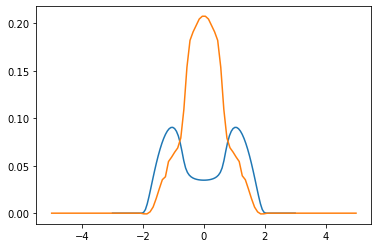

In [5]:
C.Inspect_transmission_from_SE_fit(eta = 1e-1,i=0,j=1); plt.show()
C.Inspect_transmission_from_SE_fit(eta = 1e-1,i=0,j=2); plt.show()


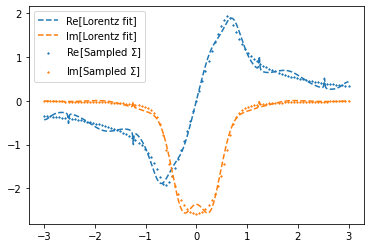

In [6]:
C.Inspect_SE_lorentzian_fit(2,8,8,0,0)

Minimum distance from Fermi-poles to Lorentzian poles: 0.4352689409773966/n
Minimum distance between Lorentzian poles: 0.5013154425136143/n
Minimum value of imaginary part of Lorentzian poles: 0.01


(0.0, 2.0)

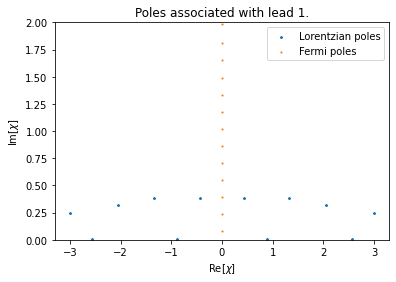

In [7]:
C.Inspect_Poles(1); plt.ylim([0,2])

## Propagation
We have now gotten to the point where we can propagate the system. The shorthands imported previously only works for the two-electrode setup, so we define our own below. We'll study what happens when one electrode lacks after the other electrode in time. 

    1. Run the code below and change the "offset" variable between 0 and 2pi
   

In [33]:
def zero_bias(t, a): return 0.0
def zero_dH(t,sig):  
    A = np.zeros(sig.shape,dtype=np.complex128)
    A[0,10,10] = 0.0
    return A

offset = 0.0
def step(t,s):
    return 1/( np.exp(-t/s +5) + 1 )

def bias(t,a):
    step_f = step(t, 1)
    if t<0:  return 0.0
    if a==0: return np.sin(t/5)/2 * step_f 
    if a==1: return -np.sin(t/5+offset)/2 * step_f
    if a==2: return 0.0


C.diagonalise()
C.get_propagation_quantities()
C.get_dense_matrices_purenp()
f     = C.make_f_purenp()
sig   = C.sigma
psi   = C.Psi_vec
omega = C.omegas
print(sig.shape, psi.shape, omega.shape)

Finding eigenvalues and eigenvectors
Maximum of eigenvalues of Lorentzian Gammas: 4.296807
Minimum of eigenvalues of Lorentzian Gammas: -0.804023
(1, 17, 17) (1, 3, 32, 1, 17) (1, 3, 32, 1, 3, 32, 17)


In [34]:
t2, data2 = RK4( f, sig, psi, omega, 1e-6,  -20,30, zero_dH, bias, C.Ixi, 0.01, fixed_mode = False, 
                 name = 'Chain', elec_names=['left', 'right', 'up'])

plt.plot(t2,data2['current left'])
plt.plot(t2,data2['current right'])
plt.plot(t2,data2['current up'])